Text length: 10,000 chars
Unique chars: 57
Sequences: (5000, 30)
Training: LSTM
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.1376 - loss: 3.4079
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.2350 - loss: 2.8830
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.2891 - loss: 2.5600
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.3347 - loss: 2.3496
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.3764 - loss: 2.1909

Training: Decoder Transformer
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.1730 - loss: 3.1976
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3528 - loss: 2.2406
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4120 - loss: 2.0010
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4471 - loss: 1.8376
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4802 - loss: 1.7031


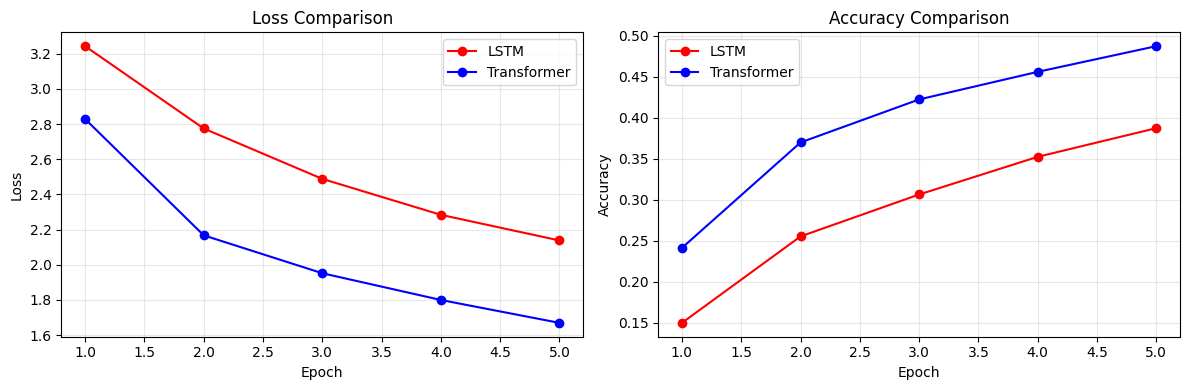

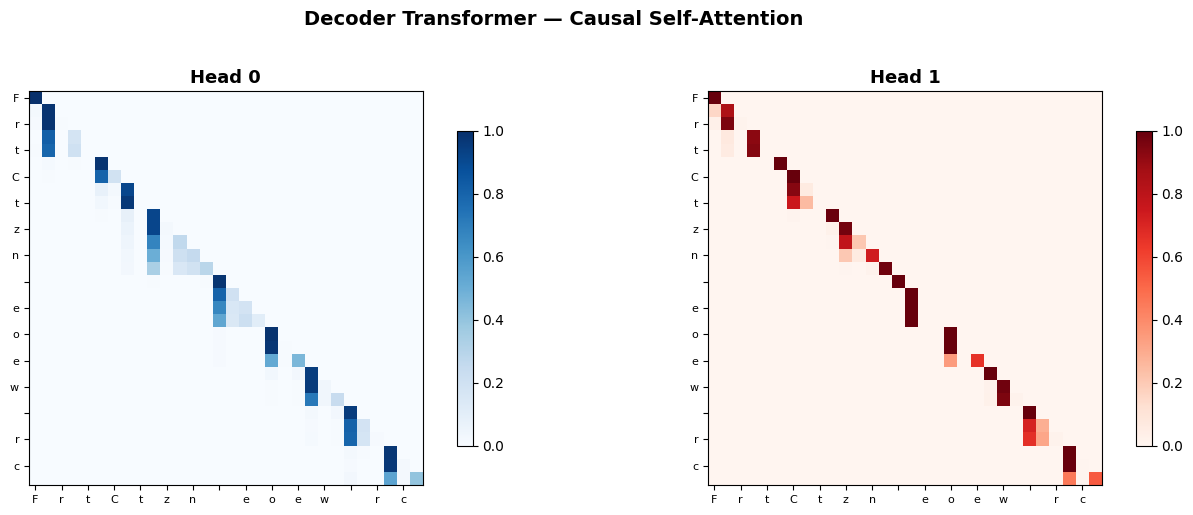


 Temperature = 0.2

[LSTM]
nt on cour with and the meall the the pare the onderer the core hear wither the pare more and the and ond the cours the pare the mare the cours ind and here the parend and the pathens and the pare the

[Decoder Transformer]
nd that and the are prake the mand the arve and us countes countes the mand the shand the are countend the arcuses ming the shand that as cound the belly are the dis praccien hand countes the belly mu

 Temperature = 0.5

[LSTM]
 the that est sellly the math and an the weirst, and und of beres heas wathings the momest reall ast one coust it and yoursss mearsy?

Sirst Citizen:
Wours aller all lerens touln, sure capeide hise ca

[Decoder Transformer]
 be arcing thate cound sther belly kneen hand sto dill he manted be accuings, whe belly shar citing pake you sull his coundes, what sing the countest for counto now lond be cor the ind whath he arver:

 Temperature = 1.0

[LSTM]
r opertse yolrsbme go gipseln:
Oe mfpenm pated
you set bapiconed o

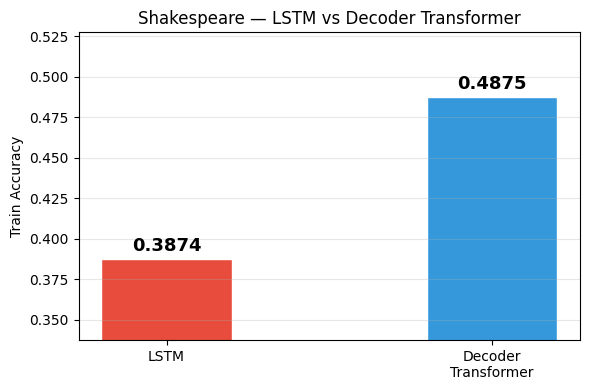

In [1]:
# ========================================================
# Week 15 : LSTM vs Decoder-only Transformer
# Character-level Text Generation (Shakespeare)
# ========================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

tf.random.set_seed(42)
np.random.seed(42)

SEQ_LEN = 30
EMBED_DIM = 64
EPOCHS = 5
BATCH = 32
NUM_SAMPLES = 5000
MAX_TOKENS = 10000

# =========================================
# 1. Load Shakespeare
# =========================================
path = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)
text = open(path, 'r').read()[:MAX_TOKENS]
print(f"Text length: {len(text):,} chars")

chars = sorted(set(text))
VOCAB_SIZE = len(chars)
print(f"Unique chars: {VOCAB_SIZE}")

char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
encoded = np.array([char_to_idx[c] for c in text])

# --- Sequence pairs: input[t] -> target[t+1] ---
X, y = [], []
for i in range(len(encoded) - SEQ_LEN):
    X.append(encoded[i:i+SEQ_LEN])
    y.append(encoded[i+1:i+SEQ_LEN+1])
X = np.array(X[:NUM_SAMPLES])
y = np.array(y[:NUM_SAMPLES])

# M2O targets (for LSTM)
y_m2o = np.array([encoded[i+SEQ_LEN] for i in range(len(encoded)-SEQ_LEN)])[:NUM_SAMPLES]

print(f"Sequences: {X.shape}")

# =========================================
# 2. Positional Encoding
# =========================================
def get_positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    dim = np.arange(d_model)[np.newaxis, :]
    angles = pos / np.power(10000, (2 * (dim // 2)) / d_model)
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(pe[np.newaxis, :, :], dtype=tf.float32)

# =========================================
# 3. Model Definitions
# =========================================

# --- LSTM (Many-to-One) ---
model_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM),
    tf.keras.layers.LSTM(256),
    tf.keras.layers.Dense(VOCAB_SIZE, activation='softmax')
])

# --- Decoder-only Transformer (Causal Mask) ---
class DecoderTransformer(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.pe = get_positional_encoding(SEQ_LEN, EMBED_DIM)
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=EMBED_DIM)
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.ffn1 = tf.keras.layers.Dense(128, activation='relu')
        self.ffn2 = tf.keras.layers.Dense(EMBED_DIM)
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.out = tf.keras.layers.Dense(VOCAB_SIZE, activation='softmax')

    def call(self, x, return_attention=False):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x) + self.pe[:, :seq_len, :]
        attn_out, attn_scores = self.mha(
            x, x, x, use_causal_mask=True, return_attention_scores=True)
        x = self.norm1(x + attn_out)
        ffn_out = self.ffn2(self.ffn1(x))
        x = self.norm2(x + ffn_out)
        logits = self.out(x)
        if return_attention:
            return logits, attn_scores
        return logits

model_tf = DecoderTransformer()

model_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# =========================================
# 4. Train Both
# =========================================
print("Training: LSTM")
h_lstm = model_lstm.fit(X, y_m2o, epochs=EPOCHS, batch_size=BATCH, verbose=1)

print("\nTraining: Decoder Transformer")
h_tf = model_tf.fit(X, y, epochs=EPOCHS, batch_size=BATCH, verbose=1)

# --- Loss & Accuracy Comparison ---
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, EPOCHS + 1)
a1.plot(ep, h_lstm.history['loss'], 'r-o', label='LSTM')
a1.plot(ep, h_tf.history['loss'], 'b-o', label='Transformer')
a1.set(title='Loss Comparison', xlabel='Epoch', ylabel='Loss'); a1.legend(); a1.grid(True, alpha=.3)
a2.plot(ep, h_lstm.history['accuracy'], 'r-o', label='LSTM')
a2.plot(ep, h_tf.history['accuracy'], 'b-o', label='Transformer')
a2.set(title='Accuracy Comparison', xlabel='Epoch', ylabel='Accuracy'); a2.legend(); a2.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

# =========================================
# 5. Attention Heatmap (Transformer)
# =========================================
sample = X[:1]
_, attn = model_tf(sample, return_attention=True)
sample_chars = [idx_to_char[i] for i in sample[0]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for head_idx, (ax, cmap, title) in enumerate(
    [(ax1, 'Blues', 'Head 0'), (ax2, 'Reds', 'Head 1')]):
    scores = attn[0, head_idx].numpy()
    im = ax.imshow(scores, cmap=cmap)
    step = max(1, len(sample_chars) // 15)
    ticks = range(0, len(sample_chars), step)
    labels = [sample_chars[i] for i in ticks]
    ax.set_xticks(ticks); ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticks(ticks); ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle('Decoder Transformer — Causal Self-Attention', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# =========================================
# 6. Temperature Generation
# =========================================
def generate_lstm(seed, length=200, temperature=1.0):
    result = list(seed)
    input_seq = [char_to_idx[c] for c in seed[-SEQ_LEN:]]
    for _ in range(length):
        x = np.array([input_seq[-SEQ_LEN:]])
        preds = model_lstm.predict(x, verbose=0)[0]
        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        next_idx = np.random.choice(len(preds), p=preds)
        result.append(idx_to_char[next_idx])
        input_seq.append(next_idx)
    return ''.join(result[len(seed):])

def generate_tf(seed, length=200, temperature=1.0):
    result = list(seed)
    input_seq = [char_to_idx[c] for c in seed[-SEQ_LEN:]]
    for _ in range(length):
        x = np.array([input_seq[-SEQ_LEN:]])
        preds = model_tf(x, return_attention=False).numpy()[0, -1]
        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        next_idx = np.random.choice(len(preds), p=preds)
        result.append(idx_to_char[next_idx])
        input_seq.append(next_idx)
    return ''.join(result[len(seed):])

seed = text[:SEQ_LEN]
temperatures = [0.2, 0.5, 1.0]

for t in temperatures:
    print(f"\n{'='*60}")
    print(f" Temperature = {t}")
    print(f"{'='*60}")
    print(f"\n[LSTM]")
    print(generate_lstm(seed, length=200, temperature=t))
    print(f"\n[Decoder Transformer]")
    print(generate_tf(seed, length=200, temperature=t))

# =========================================
# 7. Final Comparison
# =========================================
fig, ax = plt.subplots(figsize=(6, 4))
names = ['LSTM', 'Decoder\nTransformer']
accs = [h_lstm.history['accuracy'][-1], h_tf.history['accuracy'][-1]]
bars = ax.bar(names, accs, color=['#e74c3c', '#3498db'], edgecolor='white', width=0.4)
for b, v in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.4f}',
            ha='center', fontweight='bold', fontsize=13)
ax.set(title='Shakespeare — LSTM vs Decoder Transformer', ylabel='Train Accuracy')
ax.set_ylim(min(accs) - 0.05, max(accs) + 0.04)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()